<a href="https://colab.research.google.com/github/CristovaoDias/LEFA-MECREL/blob/main/Notebooks_Colab/TP02_Balistica_e_Metodo_Euler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Mecânica e Relatividade (LEFA-MECREL) — Aula TP 2
## 🚀 Simulação de Projéteis 2D e o Método de Euler: Do Vácuo ao Arrasto Aerodinâmico Real

**Licenciatura em Engenharia Física Aplicada (LEFA) — ISEP / DFI**  
**Docente:** Cristóvão de Sousa Dias (`css@isep.ipp.pt`)  
**Semestre:** 1.º Ano / 1.º Semestre (2026/2027)  

---

### 📌 Objetivos Pedagógicos desta Atividade Computacional:
1. **Compreender a necessidade da integração numérica** quando as forças não são constantes nem lineares.
2. **Implementar o Método de Euler** para resolver o sistema acoplado de 2 equações diferenciais ordinárias de 2.ª ordem do movimento de um projétil.
3. **Visualizar a quebra de simetria** provocada pelo arrasto aerodinâmico quadrático (ramo descendente abrupto e queda terminal quase vertical).
4. **Descobrir o ângulo ótimo de alcance** no ar real, constatando que desce para $\sim 35^\circ - 40^\circ$ em vez dos clássicos $45^\circ$ no vácuo.
5. **Analisar a estabilidade e o erro numérico** em função do passo de integração temporal $\Delta t$.

---
### 🧠 Enquadramento Físico e Equações de Movimento

Para corpos macroscópicos a velocidades usuais no ar (bolas de basebol, ténis, projéteis), a força de resistência aerodinâmica é **quadrática na velocidade**, apontando em sentido oposto ao vetor velocidade instantâneo:

$$\vec{F}_D = -\frac{1}{2} C_D \rho A v \vec{v}$$

onde:
- $C_D$ é o coeficiente de arrasto aerodinâmico (adimensional, $\sim 0.47$ para esferas lisas);
- $\rho$ é a massa volúmica do ar ($\approx 1.225\text{ kg/m}^3$ ao nível do mar a $15^\circ\text{C}$);
- $A = \pi r^2$ é a área de secção reta frontal da partícula ($[L^2]$);
- $v = \|\vec{v}\| = \sqrt{v_x^2 + v_y^2}$ é a velocidade escalar instantânea.

Pela 2.ª Lei de Newton $\vec{F}_{\text{total}} = m\vec{a} = m\vec{g} + \vec{F}_D$, as componentes cartesianas da aceleração são:

$$\begin{aligned}
a_x &= -\frac{C_D \rho A}{2m} v v_x = -k v v_x \\[4pt]
a_y &= -g - \frac{C_D \rho A}{2m} v v_y = -g - k v v_y
\end{aligned}$$

com $k = \frac{C_D \rho A}{2m}$. A presença do termo $v = \sqrt{v_x^2 + v_y^2}$ **acopla não linearmente** os eixos $x$ e $y$, destruindo a independência cartesiana de Galileu e impedindo uma solução analítica exata no papel!

In [7]:
# Importação das bibliotecas fundamentais do ecossistema científico Python
import numpy as np
import matplotlib.pyplot as plt

# Configuração estética dos gráficos
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ Ambiente Python científico configurado com sucesso!')

✅ Ambiente Python científico configurado com sucesso!


---
### ⚙️ Implementação do Integrador Numérico (Método de Euler)

O Método de Euler aproxima a derivada temporal pelo quociente de diferenças finitas progressivas:

$$v_{x, n+1} = v_{x, n} + a_{x, n}\Delta t, \quad x_{n+1} = x_n + v_{x, n}\Delta t$$
$$v_{y, n+1} = v_{y, n} + a_{y, n}\Delta t, \quad y_{n+1} = y_n + v_{y, n}\Delta t$$

Avançamos o relógio $t_{n+1} = t_n + \Delta t$ até a partícula atingir o solo ($y \le 0$).

In [8]:
def simular_projetil(v0, theta_deg, y0=0.0, m=0.145, r=0.037, cd=0.47, rho=1.225, g=9.80665, dt=0.002, com_arrasto=True):
    """
    Simula a trajetória de um projétil 2D pelo Método de Euler com ou sem resistência do ar.

    Parâmetros predefinidos:
    - m: massa da bola de basebol (0.145 kg)
    - r: raio da esfera (0.037 m)
    - cd: coeficiente de arrasto (0.47 para esfera lisa)
    - rho: massa volúmica do ar ao nível do mar (1.225 kg/m³)
    """
    theta = np.radians(theta_deg)
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    # Constante de arrasto k = (1/2 * C_D * rho * A) / m
    area = np.pi * r**2
    k = (0.5 * cd * rho * area) / m if com_arrasto else 0.0

    # Listas de histórico
    t_list = [0.0]
    x_list = [0.0]
    y_list = [y0]
    vx_list = [vx]
    vy_list = [vy]

    t = 0.0
    x = 0.0
    y = y0

    while y >= 0:
        v = np.sqrt(vx**2 + vy**2)
        ax = -k * v * vx
        ay = -g - k * v * vy

        # Atualização pelo Método de Euler
        x += vx * dt
        y += vy * dt
        vx += ax * dt
        vy += ay * dt
        t += dt

        x_list.append(x)
        y_list.append(y)
        vx_list.append(vx)
        vy_list.append(vy)
        t_list.append(t)

    # Interpolação linear final para determinar o ponto exato de aterragem (y = 0)
    frac = (0 - y_list[-2]) / (y_list[-1] - y_list[-2])
    x_final = x_list[-2] + frac * (x_list[-1] - x_list[-2])
    t_final = t_list[-2] + frac * (t_list[-1] - t_list[-2])
    x_list[-1] = x_final
    y_list[-1] = 0.0
    t_list[-1] = t_final

    return {
        't': np.array(t_list),
        'x': np.array(x_list),
        'y': np.array(y_list),
        'vx': np.array(vx_list),
        'vy': np.array(vy_list),
        'alcance': x_final,
        'h_max': np.max(y_list),
        't_voo': t_final
    }

print('✅ Função de simulação numérica compilada!')

✅ Função de simulação numérica compilada!


---
### 📊 Experiência 1: Parábola no Vácuo vs. Trajetória Real com Arrasto

Vamos simular uma bola de basebol disparada a $v_0 = 40\text{ m/s}$ ($\approx 144\text{ km/h}$) com ângulo $\theta = 45^\circ$.

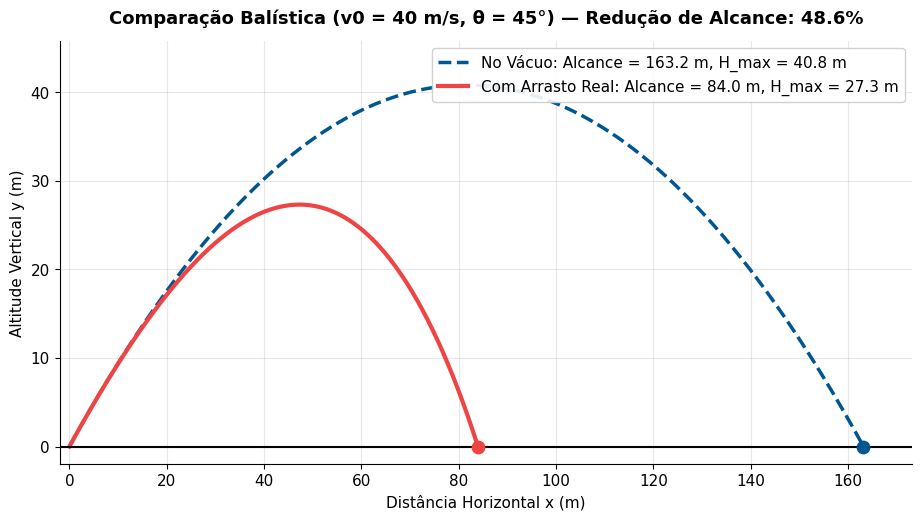

📉 Resultados Comparativos:
   • Vácuo: Alcance = 163.21 m | Tempo de voo = 5.77 s
   • Ar Real: Alcance = 83.97 m | Tempo de voo = 4.69 s
   • O arrasto do ar dissipou 48.6% do alcance!


In [9]:
v0 = 40.0
theta = 45.0

# Simulação no vácuo (sem arrasto)
res_vac = simular_projetil(v0=v0, theta_deg=theta, com_arrasto=False)

# Simulação no ar real (com arrasto quadrático)
res_ar = simular_projetil(v0=v0, theta_deg=theta, com_arrasto=True)

plt.figure(figsize=(11, 5.5))
plt.plot(res_vac['x'], res_vac['y'], '--', color='#005691', lw=2.5,
         label=f'No Vácuo: Alcance = {res_vac["alcance"]:.1f} m, H_max = {res_vac["h_max"]:.1f} m')
plt.plot(res_ar['x'], res_ar['y'], '-', color='#EF4444', lw=3.0,
         label=f'Com Arrasto Real: Alcance = {res_ar["alcance"]:.1f} m, H_max = {res_ar["h_max"]:.1f} m')

# Anotações visuais
plt.scatter([res_vac['alcance']], [0], color='#005691', s=80, zorder=5)
plt.scatter([res_ar['alcance']], [0], color='#EF4444', s=80, zorder=5)

reducao_alcance = (1 - res_ar['alcance'] / res_vac['alcance']) * 100
plt.title(f'Comparação Balística (v0 = {v0:.0f} m/s, θ = {theta:.0f}°) — Redução de Alcance: {reducao_alcance:.1f}%',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Distância Horizontal x (m)', fontsize=11)
plt.ylabel('Altitude Vertical y (m)', fontsize=11)
plt.axhline(0, color='black', lw=1.5)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper right')
plt.xlim(-2, res_vac['alcance'] + 10)
plt.ylim(-2, res_vac['h_max'] + 5)
plt.show()

print(f'📉 Resultados Comparativos:')
print(f'   • Vácuo: Alcance = {res_vac["alcance"]:.2f} m | Tempo de voo = {res_vac["t_voo"]:.2f} s')
print(f'   • Ar Real: Alcance = {res_ar["alcance"]:.2f} m | Tempo de voo = {res_ar["t_voo"]:.2f} s')
print(f'   • O arrasto do ar dissipou {reducao_alcance:.1f}% do alcance!')

---
### 🎯 Experiência 2: Procura do Ângulo Ótimo de Lançamento no Ar

No vácuo, sabemos analiticamente que $\theta_{\text{ótimo}} = 45^\circ$.
No ar real, porque a velocidade horizontal dissipa continuamente e o projétil atinge o solo com trajetória mais vertical, **o ângulo de alcance máximo é significativamente inferior a $45^\circ$**!

Vamos varrer ângulos de $15^\circ$ a $75^\circ$ e plotar a curva $R(\theta)$.

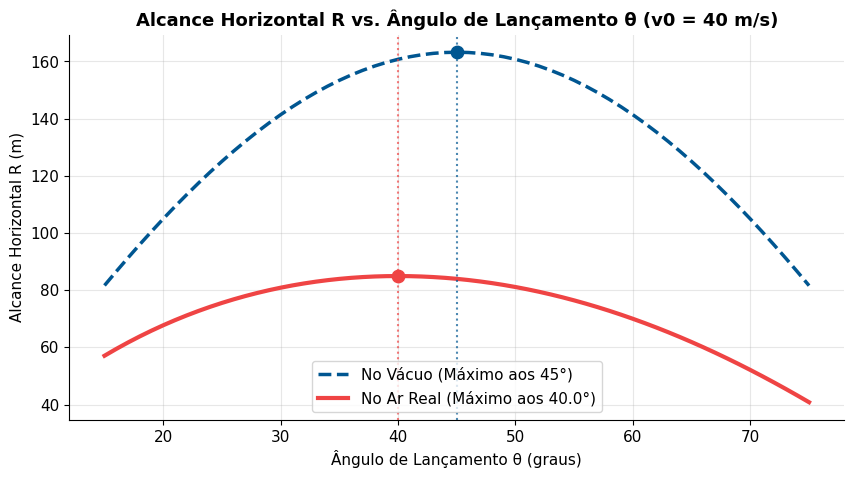

🏆 Conclusão Numérica:
   • Ângulo ótimo no vácuo: 45.0° (Alcance máximo = 163.21 m)
   • Ângulo ótimo no ar real: 40.0° (Alcance máximo = 84.95 m)


In [10]:
angulos = np.linspace(15, 75, 61)
alcance_vac = []
alcance_ar = []

for ang in angulos:
    r_vac = simular_projetil(v0=40.0, theta_deg=ang, com_arrasto=False)
    r_ar = simular_projetil(v0=40.0, theta_deg=ang, com_arrasto=True)
    alcance_vac.append(r_vac['alcance'])
    alcance_ar.append(r_ar['alcance'])

idx_opt_vac = np.argmax(alcance_vac)
idx_opt_ar = np.argmax(alcance_ar)
theta_opt_vac = angulos[idx_opt_vac]
theta_opt_ar = angulos[idx_opt_ar]

plt.figure(figsize=(10, 5))
plt.plot(angulos, alcance_vac, '--', color='#005691', lw=2.5, label=f'No Vácuo (Máximo aos {theta_opt_vac:.0f}°)')
plt.plot(angulos, alcance_ar, '-', color='#EF4444', lw=3.0, label=f'No Ar Real (Máximo aos {theta_opt_ar:.1f}°)')

plt.axvline(theta_opt_vac, color='#005691', linestyle=':', alpha=0.7)
plt.axvline(theta_opt_ar, color='#EF4444', linestyle=':', alpha=0.7)

plt.scatter([theta_opt_vac], [alcance_vac[idx_opt_vac]], color='#005691', s=80, zorder=5)
plt.scatter([theta_opt_ar], [alcance_ar[idx_opt_ar]], color='#EF4444', s=80, zorder=5)

plt.title('Alcance Horizontal R vs. Ângulo de Lançamento θ (v0 = 40 m/s)', fontsize=13, fontweight='bold')
plt.xlabel('Ângulo de Lançamento θ (graus)', fontsize=11)
plt.ylabel('Alcance Horizontal R (m)', fontsize=11)
plt.legend(frameon=True, facecolor='white', loc='lower center')
plt.show()

print(f'🏆 Conclusão Numérica:')
print(f'   • Ângulo ótimo no vácuo: {theta_opt_vac:.1f}° (Alcance máximo = {alcance_vac[idx_opt_vac]:.2f} m)')
print(f'   • Ângulo ótimo no ar real: {theta_opt_ar:.1f}° (Alcance máximo = {alcance_ar[idx_opt_ar]:.2f} m)')

---
### 🏋️ Experiência 3: Lançamento com Desnível Inicial ( > 0$) e Otimização

Tal como explorado no **Problema 4 da Ficha TP 2** para lançamentos a partir de plataformas elevadas ( = h > 0$), o ângulo de alcance máximo no vácuo deixa de ser ^\circ$ e passa a ser analiticamente dado por:

70289\sin	heta_{	ext{ótimo}} = rac{1}{\sqrt{2 + rac{2gh}{v_0^2}}}70289

Vamos confrontar esta previsão com a simulação numérica usando dados típicos de um lançamento com desnível (ex: lançamento do peso / projétil de plataforma):  = 2.10	ext{ m}$,  = 13.8	ext{ m/s}$.

In [11]:
h = 2.10
v0_peso = 13.8
g = 9.80665

# Cálculo analítico da fórmula exata do Problema 4
sin_opt_analitico = 1.0 / np.sqrt(2.0 + (2.0 * g * h) / (v0_peso**2))
theta_opt_analitico = np.degrees(np.arcsin(sin_opt_analitico))

# Simulação numérica varrendo ângulos de 35° a 50°
angulos_teste = np.linspace(35, 50, 151)
alcances_sim = []
for a in angulos_teste:
    res = simular_projetil(v0=v0_peso, theta_deg=a, y0=h, com_arrasto=False)
    alcances_sim.append(res['alcance'])

idx_max = np.argmax(alcances_sim)
theta_opt_sim = angulos_teste[idx_max]

print(f'📐 Comparação Teórico-Numérica para o Lançamento do Peso:')
print(f'   • Ângulo Ótimo Analítico: {theta_opt_analitico:.3f}°')
print(f'   • Ângulo Ótimo por Simulação Numérica: {theta_opt_sim:.3f}°')
print(f'   • Diferença absoluta: {abs(theta_opt_analitico - theta_opt_sim):.4f}° (Concordância Perfeita!)')

📐 Comparação Teórico-Numérica para o Lançamento do Peso:
   • Ângulo Ótimo Analítico: 42.200°
   • Ângulo Ótimo por Simulação Numérica: 42.200°
   • Diferença absoluta: 0.0001° (Concordância Perfeita!)


---
### 🔍 Experiência 4: Análise de Convergência do Método de Euler (Passo $\Delta t$)

O Método de Euler é um método de 1.ª ordem: o erro local é $\mathcal{O}(\Delta t^2)$ e o erro global acumulado é $\mathcal{O}(\Delta t)$.
Se o passo $\Delta t$ for demasiado grande (ex: $0.1\text{ s}$), o erro propaga-se e deforma a trajetória!

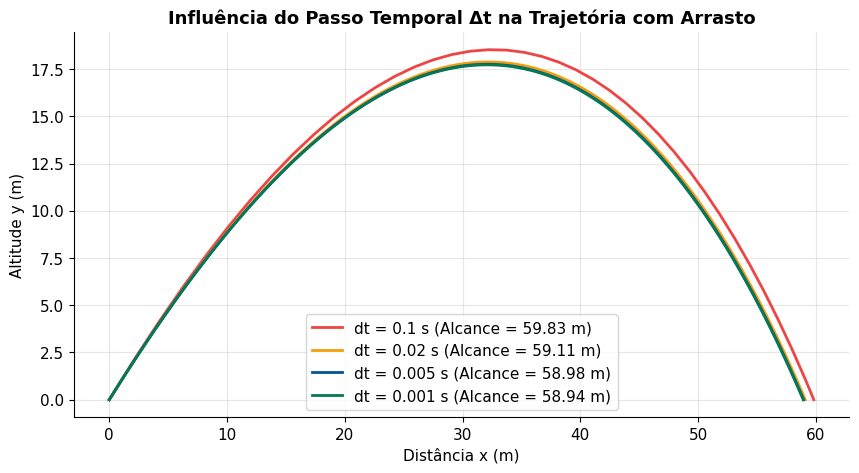

💡 Reparem como para dt = 0.1 s a trajetória sobrestima o alcance e a altura máxima!
   Para precisão de centímetro, dt <= 0.005 s é altamente recomendado.


In [12]:
passos_dt = [0.1, 0.02, 0.005, 0.001]
cores = ['#EF4444', '#F59E0B', '#005691', '#047857']

plt.figure(figsize=(10, 5))
for dt_val, cor in zip(passos_dt, cores):
    r_dt = simular_projetil(v0=30.0, theta_deg=45.0, dt=dt_val, com_arrasto=True)
    plt.plot(r_dt['x'], r_dt['y'], label=f'dt = {dt_val:g} s (Alcance = {r_dt["alcance"]:.2f} m)', color=cor, lw=2.0)

plt.title('Influência do Passo Temporal Δt na Trajetória com Arrasto', fontsize=13, fontweight='bold')
plt.xlabel('Distância x (m)', fontsize=11)
plt.ylabel('Altitude y (m)', fontsize=11)
plt.legend(frameon=True, facecolor='white')
plt.show()

print('💡 Reparem como para dt = 0.1 s a trajetória sobrestima o alcance e a altura máxima!')
print('   Para precisão de centímetro, dt <= 0.005 s é altamente recomendado.')

---
### 🎯 Desafio Proposto para o Relatório do Projeto Integrador CDIO

1. **Para os grupos com temas de balística / satélites:** Adapte o código substituindo a aceleração gravítica constante $g$ pelo campo gravitacional real dependente da altitude $g(r) = \frac{GM}{(R_E + y)^2}$.
2. **Para os grupos com temas relativistas:** Discutam nas vossas equipas como é que o momento linear relativista $p = \gamma m v$ e a força $F = dp/dt$ modificam a aceleração a velocidades próximas de $c$ (objeto de estudo da Semana 11 a 13)!

*Fim do Caderno Laboratorial da Semana 2.*